# Predicting High-Contrast Lapses in Expert Mice using Internal-State Proxies
### IBL Brain-Wide Map Dataset Project

This notebook serves as the primary dataset loading, exploratory data analysis (EDA), and feature engineering pipeline for our research project.

---

##  Project Background & Objective
When well-trained "expert" mice make errors on trivial task parameters (e.g., failing to report a high-contrast visual stimulus), computational models typically categorize these errors as "random noise" or simple "lapses" represented by a flat asymptote in a psychometric curve.

**Our Core Question:** Are these easy mistakes truly random, or can they be predicted by trackable proxies of the animal's internal state—such as fatigue, frustration, satiety, or impulsive motor biases?

---

## 📊 Variable Reference Directory
Before we begin, here is how the variables in our session data map to behavioral and experimental conditions:

### 1. Task Parameters (Independent Environmental Variables)
| Variable Name | Type | Unit / Range | Description |
| :--- | :--- | :--- | :--- |
| `contrastLeft` | Float | $[0.0, 1.0]$ | The visual contrast of the Gabor patch appearing on the left hemisphere of the screen. |
| `contrastRight` | Float | $[0.0, 1.0]$ | The visual contrast of the Gabor patch appearing on the right hemisphere of the screen. |
| `max_contrast` | Float | $[0.0, 1.0]$ | The peak sensory signal presented on the current trial ($\max(\text{Left}, \text{Right})$). |

### 2. Behavioral Response (Observed Actions)
| Variable Name | Type | Unit / Range | Description |
| :--- | :--- | :--- | :--- |
| `choice` / `response` | Integer | $\{-1, 0, 1\}$ | The action executed by the mouse: **-1** (Turned wheel Right), **1** (Turned wheel Left), **0** (No-Go / Inaction). |
| `feedbackType` | Integer | $\{-1, 1\}$ | The experimental trial outcome: **1** (Rewarded choice), **-1** (Punished/Incorrect choice). |
| `rt` (Reaction Time) | Float | Seconds ($s$) | The time difference between the visual stimulus onset (`stimOn_times`) and the wheel movement response (`response_times`). |

### 3. Proxies of Internal State (Our Engineered Features)
We use the temporal history of the mouse's behavior to infer changing internal states:
| Feature Name | Type | Unit / Range | Inferred Internal State Proxy |
| :--- | :--- | :--- | :--- |
| `prev_rt_mean` | Float | Seconds ($s$) | **Motor Speed / Engagement:** Slowing down indicates fatigue; hyper-speed suggests impulsivity. |
| `prev_rt_std` | Float | Variance ($s$) | **Attentional Stability:** High variability in response times indicates distraction or mind-wandering. |
| `prev_reward_rate` | Float | $[0.0, 1.0]$ | **Motivation / Success:** Low success rates indicate frustration or an active search for alternative task heuristics. |
| `prev_choice_bias` | Float | $[-1.0, 1.0]$ | **Motor Habituation:** Large deviations from 0.0 show the mouse is guessing purely based on physical habit. |
| `session_position` | Float | $[0.0, 1.0]$ | **Satiety / Depletion:** Normalized trial position. High values indicate water satiety and physical fatigue. |

In [1]:
# First, we install the official IBL ONE (Open Neurophysiology Environment) API
# and basic diagnostic packages.
!pip install ONE-api ibllib pandas numpy scikit-learn matplotlib seaborn tqdm --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from one.api import ONE
from brainbox.io.one import SessionLoader

print("Environment setup and libraries loaded successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5

## Step 2: Accessing the IBL Database & Session Selection
Using the `ONE` API, we establish a remote connection with the official public Alyx database hosted by the International Brain Laboratory.

We perform a query using `.search()` to isolate behavioral sessions using the standard **Biased Choice World** protocol, representing sessions from well-trained expert mice.

In [10]:
# ==============================================================================
# STEP 2: INITIALIZE ONE AND ACQUIRE EPHYS-BACKED SESSION ID
# ==============================================================================
print("Connecting to the public IBL Alyx database...")
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

print("\nSearching database for brain-wide map sessions containing neural (spikes) data...")
sessions = one.search(
    projects='brainwide',
    datasets='probes.description.json'
)

if len(sessions) == 0:
    print("Trying alternate search terms...")
    sessions = one.search(datasets='probes.description.json')

if len(sessions) == 0:
    print("Final fallback: global search for spikes...")
    sessions = one.search(datasets='spikes.times.npy')

# Ensure we found sessions before indexing
if len(sessions) > 0:
    eid = sessions[0]

    # CONVERT TO STRING TO AVOID UUID SUBSCRIPT ERROR:
    eid_str = str(eid)

    print("\n" + "="*50)
    print(f"🎉 SUCCESS! Target Session EID: {eid_str}")
    print(f"👉 Copy-paste this search term into the visualization portal: \n   eid:{eid_str[:8]}")
    print("="*50)
else:
    raise RuntimeError("Could not retrieve any sessions. Please check your internet connection or connection to Alyx.")

Connecting to the public IBL Alyx database...
Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"

Searching database for brain-wide map sessions containing neural (spikes) data...

🎉 SUCCESS! Target Session EID: ebce500b-c530-47de-8cb1-963c552703ea
👉 Copy-paste this search term into the visualization portal: 
   eid:ebce500b


## Step 3: Raw Data Loading & Alignment
The standard IBL data architecture organizes datasets using the **ALF (Analytic Layout Format)** convention. Instead of downloading manual `.npy` arrays and aligning them manually, we use `SessionLoader` from the IBL `brainbox` library.

The `SessionLoader` locates the correct collections (whether stored under `alf/` or subdirectory task names like `alf/task_00`), downloads them, reads the underlying parquet files, and structures them into a unified Pandas DataFrame named `sl.trials`.

In [11]:
# Step 3: Raw Data Loading & Alignment
print("Initiating SessionLoader for the chosen session...")
sl = SessionLoader(eid=eid, one=one)

print("Downloading and aligning raw behavioral trials table...")
sl.load_trials()
raw_df = sl.trials.copy()

print(f"\nSuccessfully created standard DataFrame! Rows: {len(raw_df)}")
print(f"Loaded columns: {list(raw_df.columns)}")

Initiating SessionLoader for the chosen session...


/usr/local/lib/python3.12/dist-packages/one/util.py:464: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 4.68k/4.68k [00:00<00:00, 18.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.intervals_bpod.npy: 100%|██████████| 9.23k/9.23k [00:00<00:00, 36.4kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.quiescencePeriod.npy: 100%|██████████| 4.68k/4.68k [00:00<00:00, 14.8kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/#2025-03-03#/_ibl_trials.stimOffTrigger_times.npy: 100%|██████████| 4.68k/4.68k [00:00<00:00, 20.0kB/s]
(S3


Successfully created standard DataFrame! Rows: 569
Loaded columns: ['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume', 'probabilityLeft', 'firstMovement_times', 'intervals_0', 'intervals_1']


In [12]:
raw_df.head()

,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,rewardVolume,probabilityLeft,firstMovement_times,intervals_0,intervals_1
0,13.648230,0.000000,2.723202,0.541949,15.099141,15.156255,13.498129,13.649192,14.099033,-1.0,13.739751,NaN,1.000,14.099118,1.0,1.5,0.5,13.976758,12.933124,15.656348
1,16.858861,3.369000,5.825702,0.457997,18.199184,18.258806,16.795460,16.859900,17.199067,1.0,16.858734,0.25,NaN,17.199169,1.0,1.5,0.5,16.982758,16.302151,18.758896
2,19.872914,6.446900,8.839602,0.426862,21.213038,21.272799,19.807112,19.873893,20.212920,-1.0,19.872693,NaN,0.250,20.213029,1.0,1.5,0.5,19.987758,19.380104,21.772851
3,23.692570,9.492900,12.639602,0.423191,25.023479,25.072820,23.631369,23.693512,24.023372,-1.0,23.692446,NaN,0.125,24.023482,1.0,1.5,0.5,23.804758,22.426161,25.572885
4,27.242310,13.249299,16.142102,0.501897,28.521440,28.575402,27.186709,27.243189,27.521317,-1.0,27.242123,NaN,0.250,27.521431,1.0,1.5,0.5,27.312758,26.182586,29.075456


## Step 4: Pre-modeling Exploratory Data Analysis (EDA)
Before altering our dataset structure to build our predictive feature arrays, we must run basic diagnostics to verify the animal's behavior.

1. **The Psychometric Curve:**
We map the signed contrast ($x$-axis) against the probability of choosing right ($y$-axis).
$$x = \text{contrastRight} - \text{contrastLeft}$$
A steep, sigmoidal transition proves the mouse is an expert.

2. **Reaction Time vs. Difficulty:**
We show how physical visual difficulty impacts the decision latency (reaction time). Harder trials (low absolute contrast) should yield slower and more variable decision speeds.

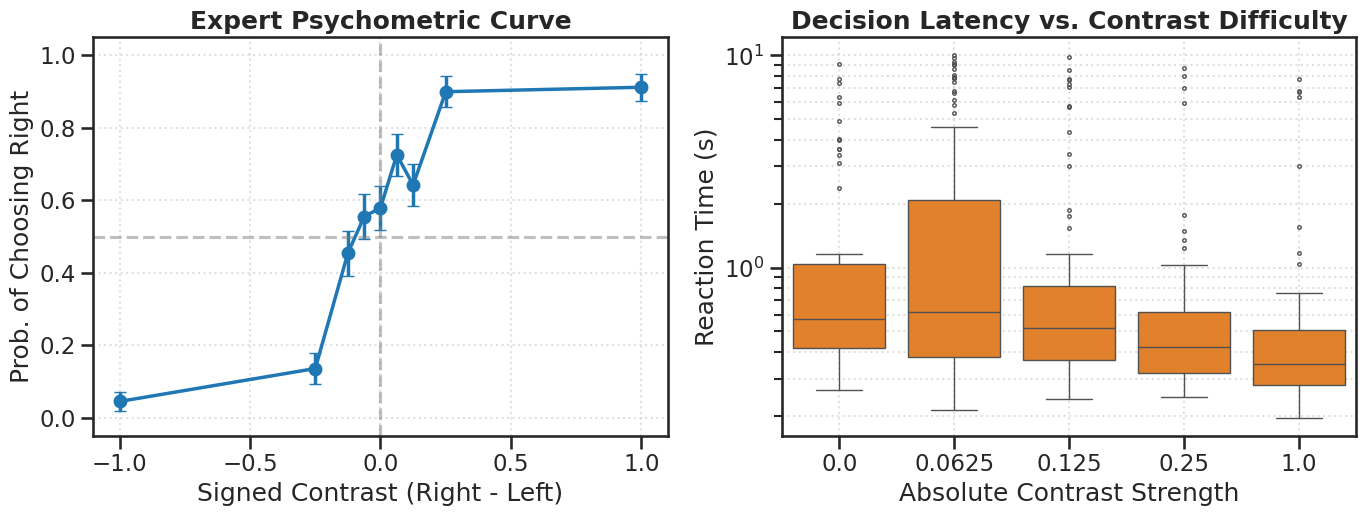

Total Session Trials: 569 | Global Accuracy: 70.3%
High-Contrast Trials: 123 | Lapses: 11 | Lapse Rate: 8.94%


In [14]:

# Set visual guidelines for Neuromatch formatting
sns.set_theme(style="ticks", context="talk")
plt.rcParams['figure.figsize'] = [14, 5.5]

# 1. Compute Signed and Absolute Contrast
raw_df['contrastLeft'] = raw_df['contrastLeft'].fillna(0.0)
raw_df['contrastRight'] = raw_df['contrastRight'].fillna(0.0)
raw_df['signed_contrast'] = raw_df['contrastRight'] - raw_df['contrastLeft']
raw_df['absolute_contrast'] = np.abs(raw_df['signed_contrast'])

# 2. Map choice orientation
raw_df['chose_right'] = (raw_df['choice'] == -1).astype(int)
raw_df['rt'] = raw_df['response_times'] - raw_df['stimOn_times']
raw_df['is_correct'] = (raw_df['feedbackType'] == 1).astype(int)

# Plotting figures
fig, axes = plt.subplots(1, 2)

# Subplot A: The Psychometric Curve
psychometric = raw_df.groupby('signed_contrast')['chose_right'].agg(['mean', 'sem']).reset_index()
axes[0].errorbar(psychometric['signed_contrast'], psychometric['mean'], yerr=psychometric['sem'],
                 fmt='o-', color='#1f77b4', linewidth=2.5, capsize=4, label='Mouse Choice')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0.0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Expert Psychometric Curve", fontweight='bold')
axes[0].set_xlabel("Signed Contrast (Right - Left)")
axes[0].set_ylabel("Prob. of Choosing Right")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot B: RT vs Difficulty
sns.boxplot(ax=axes[1], data=raw_df[raw_df['rt'] < 10], x='absolute_contrast', y='rt', color='#ff7f0e', fliersize=2.5)
axes[1].set_title("Decision Latency vs. Contrast Difficulty", fontweight='bold')
axes[1].set_xlabel("Absolute Contrast Strength")
axes[1].set_ylabel("Reaction Time (s)")
axes[1].set_yscale('log')
axes[1].grid(True, which="both", linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Print diagnostics
total_easy = len(raw_df[raw_df['absolute_contrast'] == 1.0])
easy_errors = len(raw_df[(raw_df['absolute_contrast'] == 1.0) & (raw_df['is_correct'] == 0)])
lapse_rate = (easy_errors / total_easy) * 100 if total_easy > 0 else 0.0

print(f"Total Session Trials: {len(raw_df)} | Global Accuracy: {raw_df['is_correct'].mean()*100:.1f}%")
print(f"High-Contrast Trials: {total_easy} | Lapses: {easy_errors} | Lapse Rate: {lapse_rate:.2f}%")

## Step 5: Engineering Internal State Proxies
Now, we transform our time-series trials into a specialized dataset to model and test our hypothesis.

To extract indicators of **fatigue, attention drift, and frustration**, we calculate sliding rolling windows over the *previous* $N$ trials ($N=5$).

> **⚠️ Preventing Data Leakage:** To ensure our predictive models run realistically in a pre-decision context, we strictly apply `.shift(1)` to all history vectors. This guarantees that the features used to predict an error at trial $t$ contain *no information* from trial $t$'s actual execution.

In [15]:

# STEP 5: HISTORY ROLLING WINDOW COMPUTATIONS

rolling_window = 5

# Re-assign choice representations
raw_df['response'] = raw_df['choice']  # -1 (Right), 1 (Left), 0 (No-go)

# Generate lagging features (Strictly pre-decision)
raw_df['prev_rt_mean'] = raw_df['rt'].rolling(window=rolling_window).mean().shift(1)
raw_df['prev_rt_std'] = raw_df['rt'].rolling(window=rolling_window).std().shift(1)
raw_df['prev_reward_rate'] = raw_df['is_correct'].rolling(window=rolling_window).mean().shift(1)
raw_df['prev_choice_bias'] = raw_df['response'].rolling(window=rolling_window).mean().shift(1)
raw_df['session_position'] = np.arange(len(raw_df)) / len(raw_df)

# Filter down to Easy (100% Contrast) Trials to target Lapses
high_contrast_df = raw_df[raw_df['absolute_contrast'] == 1.0].copy()

# Label 'is_lapse' (1 = incorrect choice on 100% contrast trial, 0 = correct choice)
high_contrast_df['is_lapse'] = (high_contrast_df['is_correct'] == 0).astype(int)

# Drop initial trials containing NaNs from sliding shifts
final_dataset = high_contrast_df.dropna(
    subset=['prev_rt_mean', 'prev_rt_std', 'prev_reward_rate', 'prev_choice_bias']
).copy()

print(f"Feature engineering pipeline completed!")
print(f"Total high-contrast dataset size: {len(final_dataset)} trials.")
print(f"Lapses available for modeling: {final_dataset['is_lapse'].sum()}")

Feature engineering pipeline completed!
Total high-contrast dataset size: 122 trials.
Lapses available for modeling: 11


## Step 6: Presentation Dashboard
We use the pandas styling engine to display a visually clean subset of our feature table, highlighting reaction speed variations and marking attentional lapses clearly.

In [24]:

# Configure printing parameters
pd.options.display.float_format = '{:.3f}'.format

def style_colab_trial_report(dataframe, count=10):
    preview_slice = dataframe.head(count).copy()

    # Human-readable renaming
    preview_slice = preview_slice.rename(columns={
        'rt': 'Current RT (s)',
        'prev_rt_mean': 'Hist. RT Mean (s)',
        'prev_reward_rate': 'Hist. Success Rate',
        'prev_choice_bias': 'Hist. Choice Bias',
        'session_position': 'Session Progress',
        'is_lapse': 'LAPSE (Error)'
    })

    target_columns = ['Current RT (s)', 'Hist. RT Mean (s)', 'Hist. Success Rate',
                      'Hist. Choice Bias', 'Session Progress', 'LAPSE (Error)']

    # Build styled rendering
    styled_view = (
        preview_slice[target_columns].style
        .format({
            'Current RT (s)': '{:.2f}s',
            'Hist. RT Mean (s)': '{:.2f}s',
            'Hist. Success Rate': '{:.0%}',
            'Hist. Choice Bias': '{:+.1f}',
            'Session Progress': '{:.1%}',
            'LAPSE (Error)': '{:d}'
        })
        .background_gradient(cmap='YlOrRd', subset=['Current RT (s)', 'Hist. RT Mean (s)'])
        .background_gradient(cmap='bwr', subset=['Hist. Choice Bias'], vmin=-1.0, vmax=1.0)
        .map(lambda val: 'background-color: #ffcccc; color: #990000; font-weight: bold;'
             if val == 1 else '', subset=['LAPSE (Error)'])
    )
    return styled_view

# Render dashboard
style_colab_trial_report(final_dataset, count=15)

,Current RT (s),Hist. RT Mean (s),Hist. Success Rate,Hist. Choice Bias,Session Progress,LAPSE (Error)
5,0.26s,0.33s,100%,-0.6,0.9%,0
7,0.59s,0.30s,80%,-1.0,1.2%,0
31,0.28s,0.39s,80%,-0.6,5.4%,0
34,0.27s,0.38s,100%,-1.0,6.0%,0
38,0.51s,0.28s,80%,-1.0,6.7%,0
39,0.26s,0.32s,80%,-0.6,6.9%,0
41,0.30s,0.35s,60%,-0.6,7.2%,0
42,0.33s,0.36s,80%,-0.2,7.4%,0
46,0.76s,0.48s,80%,+0.2,8.1%,0
53,0.31s,1.05s,60%,-0.6,9.3%,0


In [17]:
print(f"Number of rows (trials): {len(final_dataset)}")
print(f"Shape of the dataset: {final_dataset.shape}")

Number of rows (trials): 122
Shape of the dataset: (122, 32)


In [22]:
print(final_dataset['is_lapse'].value_counts())


is_lapse
0    111
1     11
Name: count, dtype: int64


In [23]:
# 1. Filter the dataset to isolate only the 11 lapse trials
lapse_trials_df = final_dataset[final_dataset['is_lapse'] == 1]

# 2. Render them using your custom dashboard style
style_colab_trial_report(lapse_trials_df, count=11)

,Current RT (s),Hist. RT Mean (s),Hist. Success Rate,Hist. Choice Bias,Session Progress,LAPSE (Error)
376,1.18s,3.75s,60%,-0.2,66.1%,1
383,7.76s,10.09s,60%,-0.6,67.3%,1
385,6.70s,12.88s,40%,+0.2,67.7%,1
443,3.01s,28.30s,40%,+0.0,77.9%,1
459,6.36s,54.04s,0%,+0.4,80.7%,1
503,60.00s,25.82s,60%,+0.4,88.4%,1
504,15.04s,35.04s,60%,+0.2,88.6%,1
527,1.04s,1.37s,100%,+1.0,92.6%,1
551,45.48s,38.05s,40%,+0.6,96.8%,1
552,60.00s,42.93s,40%,+0.2,97.0%,1


In [18]:
final_dataset.head()

,goCueTrigger_times,intervals_bpod_0,intervals_bpod_1,quiescencePeriod,stimOffTrigger_times,stimOff_times,stimOnTrigger_times,goCue_times,response_times,choice,...,absolute_contrast,chose_right,rt,is_correct,prev_rt_mean,prev_rt_std,prev_reward_rate,prev_choice_bias,session_position,is_lapse
5,30.473,16.755,19.356,0.567,31.736,31.789,30.421,30.474,30.736,-1.000,...,1.000,1,0.263,1,0.330,0.030,1.000,-0.600,0.009,0
7,38.609,24.366,27.823,0.646,40.200,40.256,38.558,38.610,39.200,1.000,...,1.000,0,0.591,1,0.296,0.036,0.800,-1.000,0.012,0
31,128.039,114.617,116.937,0.416,129.314,129.372,127.968,128.040,128.314,-1.000,...,1.000,1,0.275,1,0.393,0.177,0.800,-0.600,0.054,0
34,138.058,123.606,126.956,0.586,139.327,139.391,137.997,138.059,138.327,-1.000,...,1.000,1,0.269,1,0.381,0.172,1.000,-1.000,0.060,0
38,151.305,137.671,140.437,0.644,152.815,152.872,151.250,151.306,151.815,1.000,...,1.000,0,0.509,1,0.283,0.024,0.800,-1.000,0.067,0


In [19]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122 entries, 5 to 556
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   goCueTrigger_times    122 non-null    float64
 1   intervals_bpod_0      122 non-null    float64
 2   intervals_bpod_1      122 non-null    float64
 3   quiescencePeriod      122 non-null    float64
 4   stimOffTrigger_times  122 non-null    float64
 5   stimOff_times         122 non-null    float64
 6   stimOnTrigger_times   122 non-null    float64
 7   goCue_times           122 non-null    float64
 8   response_times        122 non-null    float64
 9   choice                122 non-null    float64
 10  stimOn_times          122 non-null    float64
 11  contrastLeft          122 non-null    float64
 12  contrastRight         122 non-null    float64
 13  feedback_times        122 non-null    float64
 14  feedbackType          122 non-null    float64
 15  rewardVolume          122 no